构建 Hamitonian:

In [ ]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import matplotlib.pyplot as plt
import json

L = 2  # take a 2x2 lattice
D = 2
t = 1  # tunneling/hopping
U = 0.01  # coulomb

# create the graph our fermions can hop on
lattice = nk.graph.Square(L,pbc=)


In [ ]:
lattice.draw()

AttributeError: module 'netket.hilbert' has no attribute 'Fermion'

In [9]:
n_sites

4

In [10]:
hilber_space

SpinOrbitalFermions(n_orbitals=4, s=1/2, n_fermions=4, n_fermions_per_spin=(2, 2))

In [2]:
def c(site, sz):
    return nk.operator.fermion.destroy(hilber_space, site, sz=sz)
def cdag(site, sz):
    return nk.operator.fermion.create(hilber_space, site, sz=sz)
def nc(site, sz):
    return nk.operator.fermion.number(hilber_space, site, sz=sz)

up = +1
down = -1
ham = 0.0
for sz in (up, down):
    for u, v in g.edges():
        ham += -t * cdag(u, sz) * c(v, sz) - t * cdag(v, sz) * c(u, sz)
for u in g.nodes():
    ham += U * nc(u, up) * nc(u, down)
print("type of hamiltonian =", type(ham))
print("Hamiltonian =", ham.operator_string())

fermi_ham = nkx.operator.FermiHubbardJax(hilber_space, t=t, U=U, graph=g)
disj_graph = nk.graph.disjoint_union(g, g)

type of hamiltonian = <class 'netket.operator._fermion2nd.numba.FermionOperator2nd'>
Hamiltonian = -1.0 [6^ 7] +
-1.0 [7^ 6] +
-1.0 [4^ 6] +
-1.0 [6^ 4] +
-1.0 [5^ 7] +
-1.0 [7^ 5] +
-1.0 [4^ 5] +
-1.0 [5^ 4] +
-1.0 [2^ 3] +
-1.0 [3^ 2] +
-1.0 [0^ 2] +
-1.0 [2^ 0] +
-1.0 [1^ 3] +
-1.0 [3^ 1] +
-1.0 [0^ 1] +
-1.0 [1^ 0] +
0.01 [4^ 4 0^ 0] +
0.01 [5^ 5 1^ 1] +
0.01 [6^ 6 2^ 2] +
0.01 [7^ 7 3^ 3]


In [ ]:
sampler = nk.sampler.MetropolisFermionHop(hilber_space, graph=g, n_chains=16, sweep_size=64)
# or let netket copy the graph per spin sector
saampler = nk.sampler.MetropolisFermionHop(
    hilber_space, graph=g, n_chains=16, sweep_size=64, spin_symmetric=True
)
# since the hilbert basis is a set of occupation numbers, we can take a general RBM
# we take complex parameters, since it learns sign structures more easily, and for even fermion number, the wave function might be complex
model = nk.models.RBM(alpha=1, param_dtype=complex, use_visible_bias=False)
vs = nk.vqs.MCState(sampler, model, n_discard_per_chain=10, n_samples=512)

# we will use sgd with Stochastic Reconfiguration
opt = nk.optimizer.Sgd(learning_rate=0.01)
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=True)
gs = nk.driver.VMC(ham, opt, variational_state=vs, preconditioner=sr)



In [4]:
# now run the optimization
# first step will take longer in order to compile
exp_name = "fermions_test0716"
gs.run(500, out=exp_name)

100%|██████████| 500/500 [00:23<00:00, 21.59it/s, Energy=-3.9944+0.0001j ± 0.0055 [σ²=0.0153, R̂=1.0214]]


(JsonLog('fermions_test0716', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.08825182914733887
   	Params: 0.08530974388122559,)

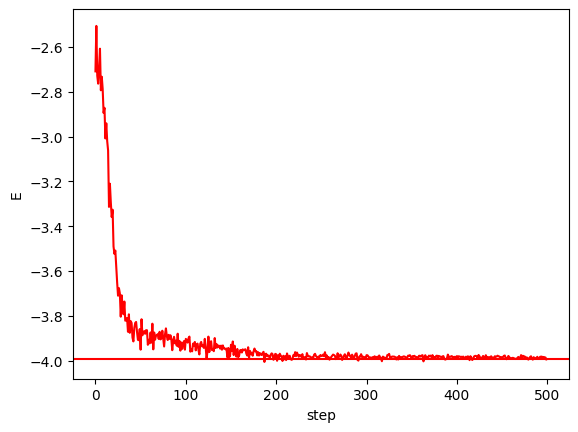

In [6]:
ed_energies = np.linalg.eigvalsh(ham.to_dense())

with open(f"{exp_name}.log") as f:
    data = json.load(f)
    

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]["real"]

# plot the energy levels
plt.axhline(ed_energies[0], color="red", label="E0")
# for e in ed_energies[1:]:
#     plt.axhline(e, color="black")
plt.plot(x, y, color="red", label="VMC")
plt.xlabel("step")
plt.ylabel("E")
plt.show()